# Cluster analysis

This notebook generates pattern duration plots with cluster transition networks.

In [1]:
import numpy as np
import mpltern # noqa: F401
from mpltern.datasets import get_triangular_grid
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.cluster import HDBSCAN
from rhythmic_segments import RhythmicSegments
from rhythmic_segments.patterns import integer_ratio_patterns

# Local imports
import sys
sys.path.append('../')
from src.utils import load_synthetic_intervals, savefig, set_mpl_style, set_figsize_cm
set_mpl_style()
from src.patdur import (
    pattern_duration_plot, 
    quantal_pattern_duration_plot, 
    DEFAULT_RATIO_LABEL, 
)
from src.plotting import inset_cbar
from src.cluster import show_cluster_transition_network, cluster_transition_network

# Whether to refresh figures
REFRESH = False

In [2]:
# Load synthetic repeated data
datasets = load_synthetic_intervals()
intervals = datasets[-1]['intervals']
rs2 = RhythmicSegments.from_intervals(intervals, length=2)
rs3 = RhythmicSegments.from_intervals(intervals, length=3)

## 2D cluster transition network

In [3]:
# Use whatever clustering method to label each segment with its cluster
np.random.seed(0)
model = HDBSCAN(min_cluster_size=5)
data = np.array([rs2.patterns[:, 0], rs2.durations]).T
labels = model.fit_predict(data)
rs2.meta['label'] = [str(l) for l in labels]

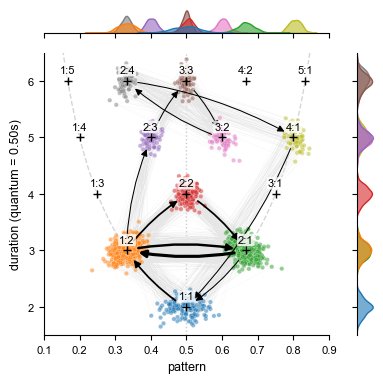

In [4]:
# Show a pattern duration plot, but now colored by label value,
# with a cluster graph on top
g = pattern_duration_plot(rs2, hue='label')
g.ax_joint.plot(rs2.patterns[:, 0], rs2.durations, c='.9', lw=0.1, zorder=-1)
set_figsize_cm(10, 10)
quantal_pattern_duration_plot(quantum=.5, ax=g.ax_joint)
show_cluster_transition_network(rs2, 'label')
g.ax_joint.set_ylim(.75, 3.25)
g.ax_joint.set_xlim(.1, .9)
g.ax_joint.legend_.remove()

plt.tight_layout()
savefig('cluster-analysis', refresh=REFRESH)

## 3D cluster transition network

In [5]:
# Use whatever clustering method to label each segment with its cluster
np.random.seed(1)
model_3d = HDBSCAN()
data = np.column_stack((rs3.patterns[:, :-1], rs3.durations))
labels = model_3d.fit_predict(data)
rs3.meta['label'] = [str(l) for l in labels]
print(f'Omitting {np.sum(labels == -1)} out of {len(labels)} unclassified segments')
subset = rs3.query('label != "-1"')

Omitting 2 out of 1498 unclassified segments


In [6]:
def bary_to_xy(ax, bary):
    # bary must be (t, l, r) with t + l + r = 1
    return tuple(ax.transProjection.transform(bary))

def show_cluster_transition_network_3d(
    rs: RhythmicSegments,
    column: str,
    ax=None,
):
    """Draw the cluster transition graph."""
    if ax is None:
        ax = plt.subplot(projection="ternary")
    graph = cluster_transition_network(rs, column=column)
    pos = nx.get_node_attributes(graph, "pos")
    pos_xy = {node: bary_to_xy(ax, [p1, p2, 1-(p1+p2)]) for node, (p1, p2, _) in pos.items()}
    edge_weights = [.5*w for w in nx.get_edge_attributes(graph, "weight").values()]

    nx.draw_networkx_edges(
        graph,
        pos_xy,
        width=edge_weights,
        arrows=True,
        arrowsize=10,
        ax=ax,
        connectionstyle="arc3,rad=-0.20",
    )
    ax.set_axis_on()
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

In [7]:
def get_markers(factors, remove=[], append=[], length=3):
    _, markers = integer_ratio_patterns(factors, length)
    markers = set([tuple(m) for m in markers.tolist() + append])
    markers = markers.difference([tuple(r) for r in remove])
    markers = np.array([list(m) for m in markers])
    patterns = markers / markers.sum(axis=1)[:, np.newaxis]
    return patterns, markers

markers, patterns = get_markers([1, 2, 3])

In [8]:
def label_axes(ax):
    kwargs_label = {
        'transform': ax.transTernaryAxes,
        'backgroundcolor': 'w',
        'ha': 'center',
        'va': 'center',
        'rotation_mode': 'anchor',
        'zorder': -9,  # A bit higher on arrows, but still lower than others.
    }
    ax.text(.55, -.1, .55, '$\\leftarrow$ Interval 1'  , rotation=-60, **kwargs_label)
    ax.text(.55, .55, -.1, '$\\leftarrow$ Interval 2' , rotation= 60, **kwargs_label)
    ax.text(-.1, .55, .55, 'Interval 3 $\\rightarrow$', rotation=  0, **kwargs_label)

/var/folders/3y/17nlr6253yx1qph213774wpw0000gn/T/ipykernel_56947/2044484578.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


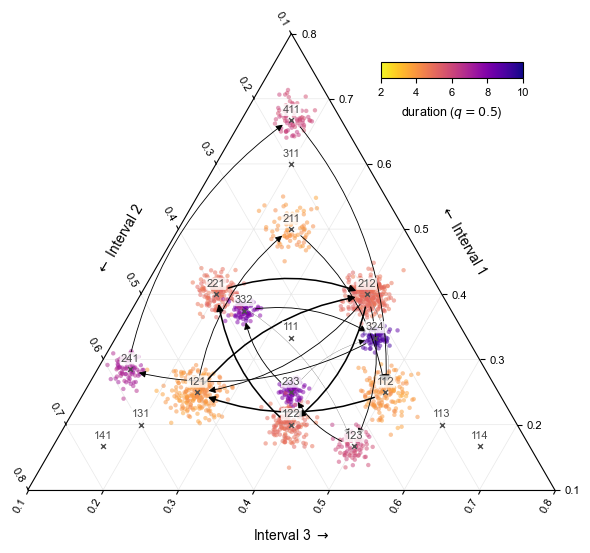

In [9]:
from matplotlib.colors import Normalize

DEFAULT_RATIO_LABEL['color'] = '0.3'

def annotate_ratio(pattern, label, ax=None):
    if ax is None: ax = plt.gca()
    a, b, c = pattern
    ax.scatter([a], [b], [c], marker='x', color='0.3', s=12, lw=1)
    x, y = bary_to_xy(ax, pattern)
    ax.annotate(label, xy=(x, y), **DEFAULT_RATIO_LABEL)

## For coloring per cluster
# cmap = plt.get_cmap('plasma')
# num_labels = len(subset.meta['label'].unique())
# colors = [cmap(int(label) / num_labels) for label in subset.meta['label']]

plt.figure(figsize=(6, 6))
ax = plt.subplot(projection="ternary")
top, left, right = subset.patterns.T
cnorm = Normalize(vmin=2, vmax=10)
ax.scatter(top, left, right, 
           s=10, alpha=.5, lw=0, 
           # Color by segment duration
           c=subset.durations / .5, cmap='plasma_r', norm=cnorm)

ax.triplot(*get_triangular_grid(11), c='.7', lw=.5, alpha=0.3)
show_cluster_transition_network_3d(subset, 'label', ax=ax)
ax.set_ternary_lim(*([.1, .9]*3))

inset_cbar(cnorm, ax=plt.gca(), label='duration ($q=0.5$)', cmap='plasma_r')

patterns, markers = get_markers(
    [1, 2, 3], 
    append=[[4, 1, 1], [1, 4, 1], [1, 1, 4], [2, 4, 1], (3, 2, 4)], 
    remove=[
        (3, 2, 1), (3, 1, 2), (3, 2, 2), (2, 3, 1), (2, 3, 2), (2, 1, 3),
        (1, 3, 2), (2, 2, 3), (3, 2, 3), (3, 3, 1), (3, 1, 3), (1, 3, 3)
    ]
)
for pattern, label in zip(patterns, markers):
    # x, y = bary_to_xy(ax, pat)
    annotate_ratio(pattern, "".join([str(l) for l in label]), ax=ax)

label_axes(ax)
plt.tight_layout()
savefig('cluster-analysis-3d', refresh=REFRESH)

## Beyond 3d

You could of course go on to visualize segments of longer lengths using dimensionality reduction techniques such as UMAP.

In [10]:
import umap

/Users/bas/repos/papers/rsa/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# Use whatever clustering method to label each segment with its cluster
np.random.seed(1)
rs5 = RhythmicSegments.from_intervals(intervals, length=5)
model_5d = HDBSCAN()
data_5d = np.column_stack((rs5.patterns[:, :-1], rs5.durations))
labels = model_5d.fit_predict(data_5d)
rs5.meta['label'] = [str(l) for l in labels]
print(f'Omitting {np.sum(labels == -1)} out of {len(labels)} unclassified segments')
subset = rs5.query('label != "-1"')

Omitting 18 out of 1496 unclassified segments


In [12]:
umap_model = umap.UMAP(n_neighbors=10, min_dist=.2, metric="euclidean", random_state=42)
embedding = umap_model.fit_transform(data_5d)

/Users/bas/repos/papers/rsa/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


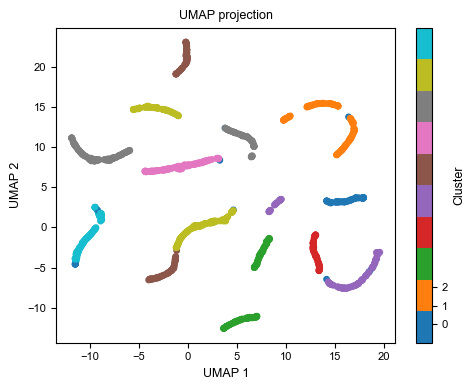

In [13]:
# Plot
plt.figure(figsize=(5, 4))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10", s=15)
plt.colorbar(scatter, ticks=[0, 1, 2], label="Cluster", )
plt.title("UMAP projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()